# learning

In [13]:
def ingest_libreview_csv(path):
    """
    Deterministic ingestion of LibreView glucose CSV.
    Produces:
      df_raw_clean  – normalized timestamp + glucose
      df_daily_avg  – daily average glucose
    """
    import pandas as pd
    df = pd.read_csv(path)

    # --- Normalize timestamp ---
    ts_col = "Device Timestamp"
    df[ts_col] = pd.to_datetime(df[ts_col], errors="coerce")

    # --- Extract glucose values ---
    df["Glucose_mgdl"] = (
        df["Historic Glucose mg/dL"]
        .fillna(df["Scan Glucose mg/dL"])
        .astype("float")
    )

    # --- Drop rows without glucose ---
    df = df.dropna(subset=["Glucose_mgdl"])

    # --- Normalize source type ---
    df["SourceType"] = df.apply(
        lambda r: "historic" if pd.notna(r["Historic Glucose mg/dL"]) else "scan",
        axis=1
    )

    # --- Select deterministic schema ---
    df_raw_clean = df[[ts_col, "Glucose_mgdl", "SourceType"]].rename(
        columns={ts_col: "Timestamp"}
    ).sort_values("Timestamp")

    # --- Compute daily averages ---
    df_daily_avg = (
        df_raw_clean
        .set_index("Timestamp")
        .resample("1D")["Glucose_mgdl"]
        .mean()
        .reset_index()
        .rename(columns={"Glucose_mgdl": "DailyAvg_mgdl"})
    )

    return df_raw_clean, df_daily_avg


In [ ]:
path = "C:\Users\bhuns\OneDrive\_Glucose\BillHunsinger_glucose_7-2-2026.csv"

In [24]:
path = r"C:\Users\bhuns\OneDrive\_Glucose\BillHunsinger_glucose_7-2-2026.csv"


In [20]:
path = r"C:\Users\bhuns\OneDrive\_Glucose\BillHunsinger_glucose_7-2-2026.csv"


In [26]:
# verify 
path

'C:\\Users\\bhuns\\OneDrive\\_Glucose\\BillHunsinger_glucose_7-2-2026.csv'

In [ ]:
df_raw, df_daily = ingest_libreview_csv(path)


In [ ]:
"C:\Users\bhuns\OneDrive\_Glucose\BillHunsinger_glucose_7-2-2026.csv"

In [ ]:
import pandas as pd

path = r"C:\Users\bhuns\OneDrive\_Glucose\BillHunsinger_glucose_7-2-2026.csv"
df = pd.read_csv(path)

df.head()


In [ ]:
import os

print(os.listdir(r"C:\Users\bhuns\OneDrive"))


In [ ]:
import os

print(os.listdir(r"C:\Users\bhuns"))


In [ ]:
import os
print(os.listdir(r"C:\Users"))


In [31]:
ls /mnt/c/Users/bhuns/OneDrive/_Glucose


BillHunsinger_glucose_7-2-2026.csv*


In [34]:
import pandas as pd

path = "/mnt/c/Users/bhuns/OneDrive/_Glucose/BillHunsinger_glucose_7-2-2026.csv"
df = pd.read_csv(path)

df.head()


/tmp/ipykernel_343/1134860226.py:4: DtypeWarning: Columns (3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


Glucose Data  \
Device              Serial Number                        Device Timestamp    Record Type Historic Glucose mg/dL Scan Glucose mg/dL Non-numeric Rapid-Acting Insulin Rapid-Acting Insulin (units) Non-numeric Food Carbohydrates (grams) Carbohydrates (servings) Non-numeric Long-Acting Insulin Long-Acting Insulin (units) Notes  Strip Glucose mg/dL   
FreeStyle LibreLink 1CBB459E-1EE9-4D31-B93C-E6C62E27C36F 06-30-2022 12:58 PM 0           107                    NaN                NaN                              NaN                          NaN              NaN                   NaN                      NaN                             NaN                         NaN                    NaN   
                                                         06-30-2022 01:13 PM 0           118                    NaN                NaN                              NaN                          NaN              NaN                   NaN                      NaN                             NaN                         NaN                    NaN   
                                                         06-30-2022 01:28 PM 0           125                    NaN                NaN                              NaN                          NaN              NaN                   NaN                      NaN                             NaN                         NaN                    NaN   
                                                         06-30-2022 01:43 PM 0           113                    NaN                NaN                              NaN                          NaN              NaN                   NaN                      NaN                             NaN                         NaN                    NaN   

                                                                                                                                                                                                                                                                                                                                     Generated on  \
Device              Serial Number                        Device Timestamp    Record Type Historic Glucose mg/dL Scan Glucose mg/dL Non-numeric Rapid-Acting Insulin Rapid-Acting Insulin (units) Non-numeric Food Carbohydrates (grams) Carbohydrates (servings) Non-numeric Long-Acting Insulin Long-Acting Insulin (units) Notes  Ketone mmol/L   
FreeStyle LibreLink 1CBB459E-1EE9-4D31-B93C-E6C62E27C36F 06-30-2022 12:58 PM 0           107                    NaN                NaN                              NaN                          NaN              NaN                   NaN                      NaN                             NaN                         NaN              NaN   
                                                         06-30-2022 01:13 PM 0           118                    NaN                NaN                              NaN                          NaN              NaN                   NaN                      NaN                             NaN                         NaN              NaN   
                                                         06-30-2022 01:28 PM 0           125                    NaN                NaN                              NaN                          NaN              NaN                   NaN                      NaN                             NaN                         NaN              NaN   
                                                         06-30-2022 01:43 PM 0           113                    NaN                NaN                              NaN                          NaN              NaN                   NaN                      NaN                             NaN                         NaN              NaN   

                                                                                                                                                                                                         

In [35]:
import pandas as pd

def ingest_glucose_daily(path):
    """
    Extract timestamp + glucose, compute daily averages,
    insert blanks for missing days, and add dtv column.
    """

    # Load CSV (LibreView mixed types → low_memory=False)
    df = pd.read_csv(path, low_memory=False)

    # Normalize timestamp
    ts_col = "Device Timestamp"
    df[ts_col] = pd.to_datetime(df[ts_col], errors="coerce")

    # Extract glucose (historic OR scan)
    df["glucose"] = (
        df["Historic Glucose mg/dL"]
        .fillna(df["Scan Glucose mg/dL"])
        .astype(float)
    )

    # Keep only rows with valid glucose + timestamp
    df = df.dropna(subset=[ts_col, "glucose"])

    # --- DAILY AVERAGE ---
    df_daily = (
        df.set_index(ts_col)
          .resample("1D")["glucose"]
          .mean()
          .to_frame("DailyAvg")
    )

    # --- INSERT BLANKS FOR MISSING DAYS ---
    # Build full date range from min → max
    full_range = pd.date_range(
        start=df_daily.index.min(),
        end=df_daily.index.max(),
        freq="D"
    )

    df_daily = df_daily.reindex(full_range)

    # --- ADD dtv COLUMN ---
    # dtv = YYYYMMDD integer
    df_daily["dtv"] = df_daily.index.strftime("%Y%m%d").astype(int)

    # Reset index for clean table
    df_daily = df_daily.reset_index().rename(columns={"index": "Timestamp"})

    return df_daily


In [40]:
df_daily = ingest_glucose_daily(
    "/mnt/c/Users/bhuns/OneDrive/_Glucose/BillHunsinger_glucose_7-2-2026.csv"
)


KeyError: 'Device Timestamp'

In [38]:
import pandas as pd

df = pd.read_csv(path, low_memory=False)
print(df.columns)


Index(['Glucose Data', 'Generated on', '07-02-2026 07:15 PM UTC',
       'Generated by', 'Bill Hunsinger'],
      dtype='object')


In [39]:
import pandas as pd

def load_libreview_csv(path):
    # Read raw file as text
    with open(path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    # Find the first line that looks like a CSV header
    header_idx = None
    for i, line in enumerate(lines):
        if "," in line and "Glucose" in line:
            header_idx = i
            break

    if header_idx is None:
        raise ValueError("Could not find a valid LibreView header row.")

    # Now read the CSV starting at the detected header
    df = pd.read_csv(path, skiprows=header_idx)

    return df


In [41]:
load_libreview_csv(path)

/tmp/ipykernel_343/437754619.py:19: DtypeWarning: Columns (3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, skiprows=header_idx)


Glucose Data  \
Device              Serial Number                        Device Timestamp    Record Type Historic Glucose mg/dL Scan Glucose mg/dL Non-numeric Rapid-Acting Insulin Rapid-Acting Insulin (units) Non-numeric Food Carbohydrates (grams) Carbohydrates (servings) Non-numeric Long-Acting Insulin Long-Acting Insulin (units) Notes                   Strip Glucose mg/dL   
FreeStyle LibreLink 1CBB459E-1EE9-4D31-B93C-E6C62E27C36F 06-30-2022 12:58 PM 0           107                    NaN                NaN                              NaN                          NaN              NaN                   NaN                      NaN                             NaN                         NaN                                     NaN   
                                                         06-30-2022 01:13 PM 0           118                    NaN                NaN                              NaN                          NaN              NaN                   NaN                      NaN                             NaN                         NaN                                     NaN   
                                                         06-30-2022 01:28 PM 0           125                    NaN                NaN                              NaN                          NaN              NaN                   NaN                      NaN                             NaN                         NaN                                     NaN   
                                                         06-30-2022 01:43 PM 0           113                    NaN                NaN                              NaN                          NaN              NaN                   NaN                      NaN                             NaN                         NaN                                     NaN   
...                                                                                                                                                                                                                                                                                                                                                                  ...   
                                                         07-01-2026 11:12 PM 6           NaN                    NaN                NaN                              NaN                          NaN              NaN                   NaN                      NaN                             NaN                         Bed                                     NaN   
                                                         07-01-2026 11:25 PM 6           NaN                    NaN                NaN                              NaN                          NaN              NaN                   NaN                      NaN                             NaN                         Bes                                     NaN   
                                                         07-02-2026 03:15 AM 6           NaN                    NaN                NaN                              NaN                          NaN              NaN                   NaN                      NaN                             NaN                         315 exercise                            NaN   
                                                         07-02-2026 02:08 PM 6           NaN                    NaN                NaN                              NaN                          NaN              NaN                   NaN                      NaN                             NaN                         Half a salad for lunch                  NaN   
FreeStyle Libre 3   6A9DBAAD-C8DD-4343-8F10-3ECFD264E083 06-12-2024 08:02 AM 6           NaN                    NaN                NaN                              NaN                          NaN              NaN                   NaN                      NaN                             NaN                         NaN                        

# working 1 function versions

In [44]:
import pandas as pd

def ingest_glucose_daily(path):
    """
    One-function LibreView ingestion:
    - Skip metadata lines
    - Detect header row containing 'Device Timestamp'
    - Extract timestamp + glucose
    - Compute daily averages
    - Insert blank days
    - Add dtv (YYYYMMDD)
    """

    # --- STEP 1: Read raw file as text ---
    with open(path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    # --- STEP 2: Detect the real header row ---
    header_idx = None
    for i, line in enumerate(lines):
        # The real header row ALWAYS contains "Device Timestamp"
        if "Device Timestamp" in line:
            header_idx = i
            break

    if header_idx is None:
        raise ValueError("Could not find LibreView header row containing 'Device Timestamp'.")

    # --- STEP 3: Load CSV starting at the header ---
    df = pd.read_csv(path, skiprows=header_idx, low_memory=False)

    # --- STEP 4: Timestamp column ---
    ts_col = "Device Timestamp"
    df[ts_col] = pd.to_datetime(df[ts_col], errors="coerce")

    # --- STEP 5: Glucose column (historic + scan) ---
    df["glucose"] = (
        df["Historic Glucose mg/dL"]
        .fillna(df["Scan Glucose mg/dL"])
        .astype(float)
    )

    # --- STEP 6: Clean rows ---
    df = df.dropna(subset=[ts_col, "glucose"])

    # --- STEP 7: Compute daily averages ---
    df_daily = (
        df.set_index(ts_col)
          .resample("1D")["glucose"]
          .mean()
          .to_frame("DailyAvg")
    )

    # --- STEP 8: Insert blank days ---
    full_range = pd.date_range(
        start=df_daily.index.min(),
        end=df_daily.index.max(),
        freq="D"
    )
    df_daily = df_daily.reindex(full_range)

    # --- STEP 9: Add dtv (YYYYMMDD integer) ---
    df_daily["dtv"] = df_daily.index.strftime("%Y%m%d").astype(int)

    # --- STEP 10: Final clean table ---
    df_daily = df_daily.reset_index().rename(columns={"index": "Timestamp"})

    return df_daily


In [45]:
df_daily = ingest_glucose_daily(
    "/mnt/c/Users/bhuns/OneDrive/_Glucose/BillHunsinger_glucose_7-2-2026.csv"
)


In [47]:
# df_daily.head()
# verify 
df_daily

,Timestamp,DailyAvg,dtv
0,2022-06-30,122.203125,20220630
1,2022-07-01,106.445312,20220701
2,2022-07-02,94.222222,20220702
3,2022-07-03,96.307692,20220703
4,2022-07-04,99.619469,20220704
...,...,...,...
1459,2026-06-28,98.415094,20260628
1460,2026-06-29,86.566038,20260629
1461,2026-06-30,95.644231,20260630
1462,2026-07-01,94.851852,20260701


In [48]:
import matplotlib.pyplot as plt

def plot_glucose_range(df_daily, start_date, end_date):
    """
    Plot daily glucose averages over a specified date range.
    
    Parameters
    ----------
    df_daily : DataFrame
        Output from ingest_glucose_daily()
        Must contain columns: Timestamp, DailyAvg, dtv

    start_date : str or datetime
        e.g. "2026-06-01"

    end_date : str or datetime
        e.g. "2026-07-15"
    """

    # Convert to datetime
    df = df_daily.copy()
    df["Timestamp"] = pd.to_datetime(df["Timestamp"])

    # Filter by date range
    mask = (df["Timestamp"] >= pd.to_datetime(start_date)) & \
           (df["Timestamp"] <= pd.to_datetime(end_date))
    df_range = df.loc[mask]

    # Plot
    plt.figure(figsize=(12, 5))
    plt.plot(df_range["Timestamp"], df_range["DailyAvg"], 
             marker="o", linestyle="-", color="blue")

    plt.title(f"Daily Glucose Average\n{start_date} → {end_date}")
    plt.xlabel("Date")
    plt.ylabel("Glucose (mg/dL)")
    plt.grid(True, alpha=0.3)

    # Rotate dates for readability
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()


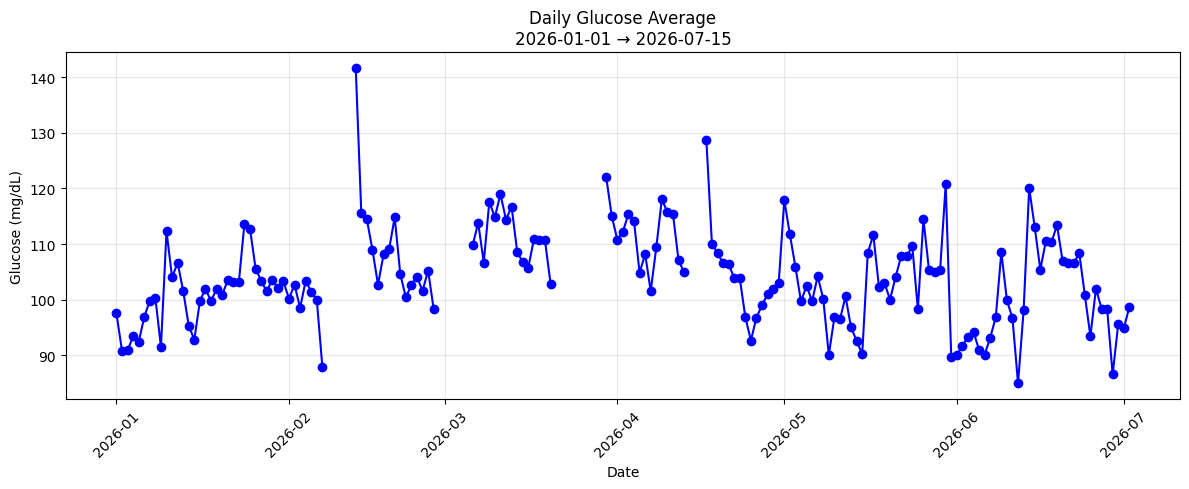

In [51]:
plot_glucose_range(df_daily, "2026-01-01", "2026-07-15")


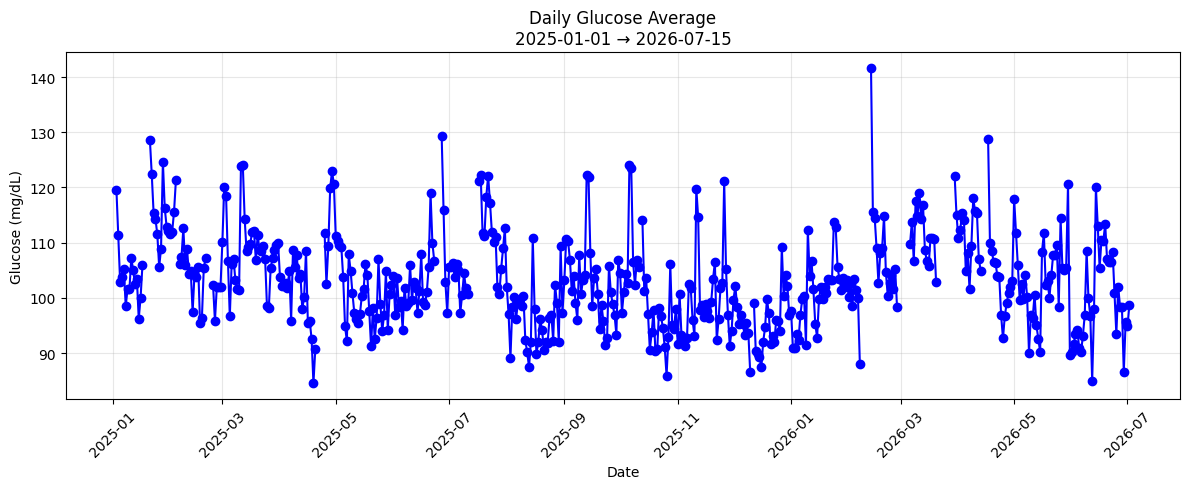

In [52]:
plot_glucose_range(df_daily, "2025-01-01", "2026-07-15")

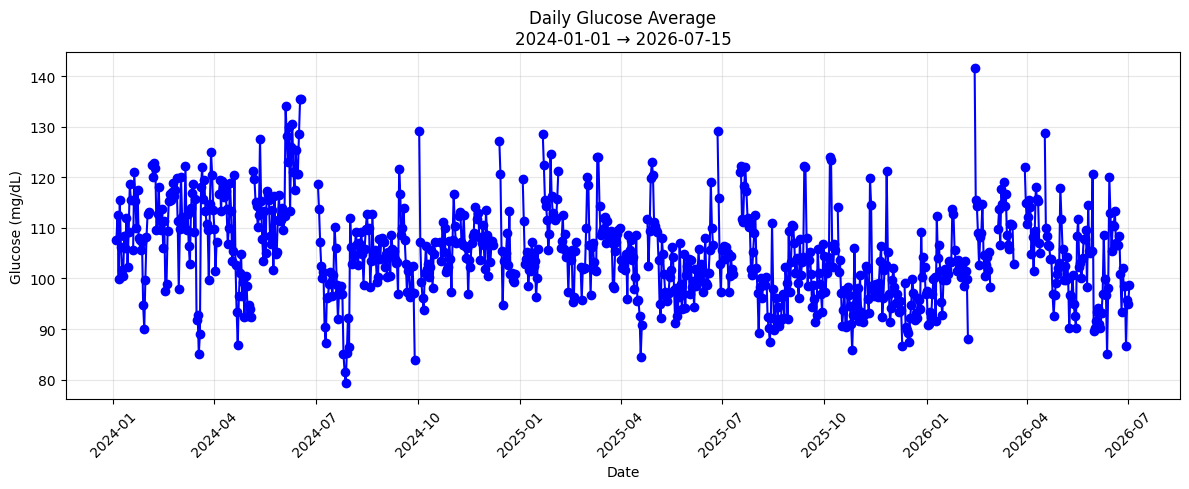

In [53]:
plot_glucose_range(df_daily, "2024-01-01", "2026-07-15")